### What is Threading?

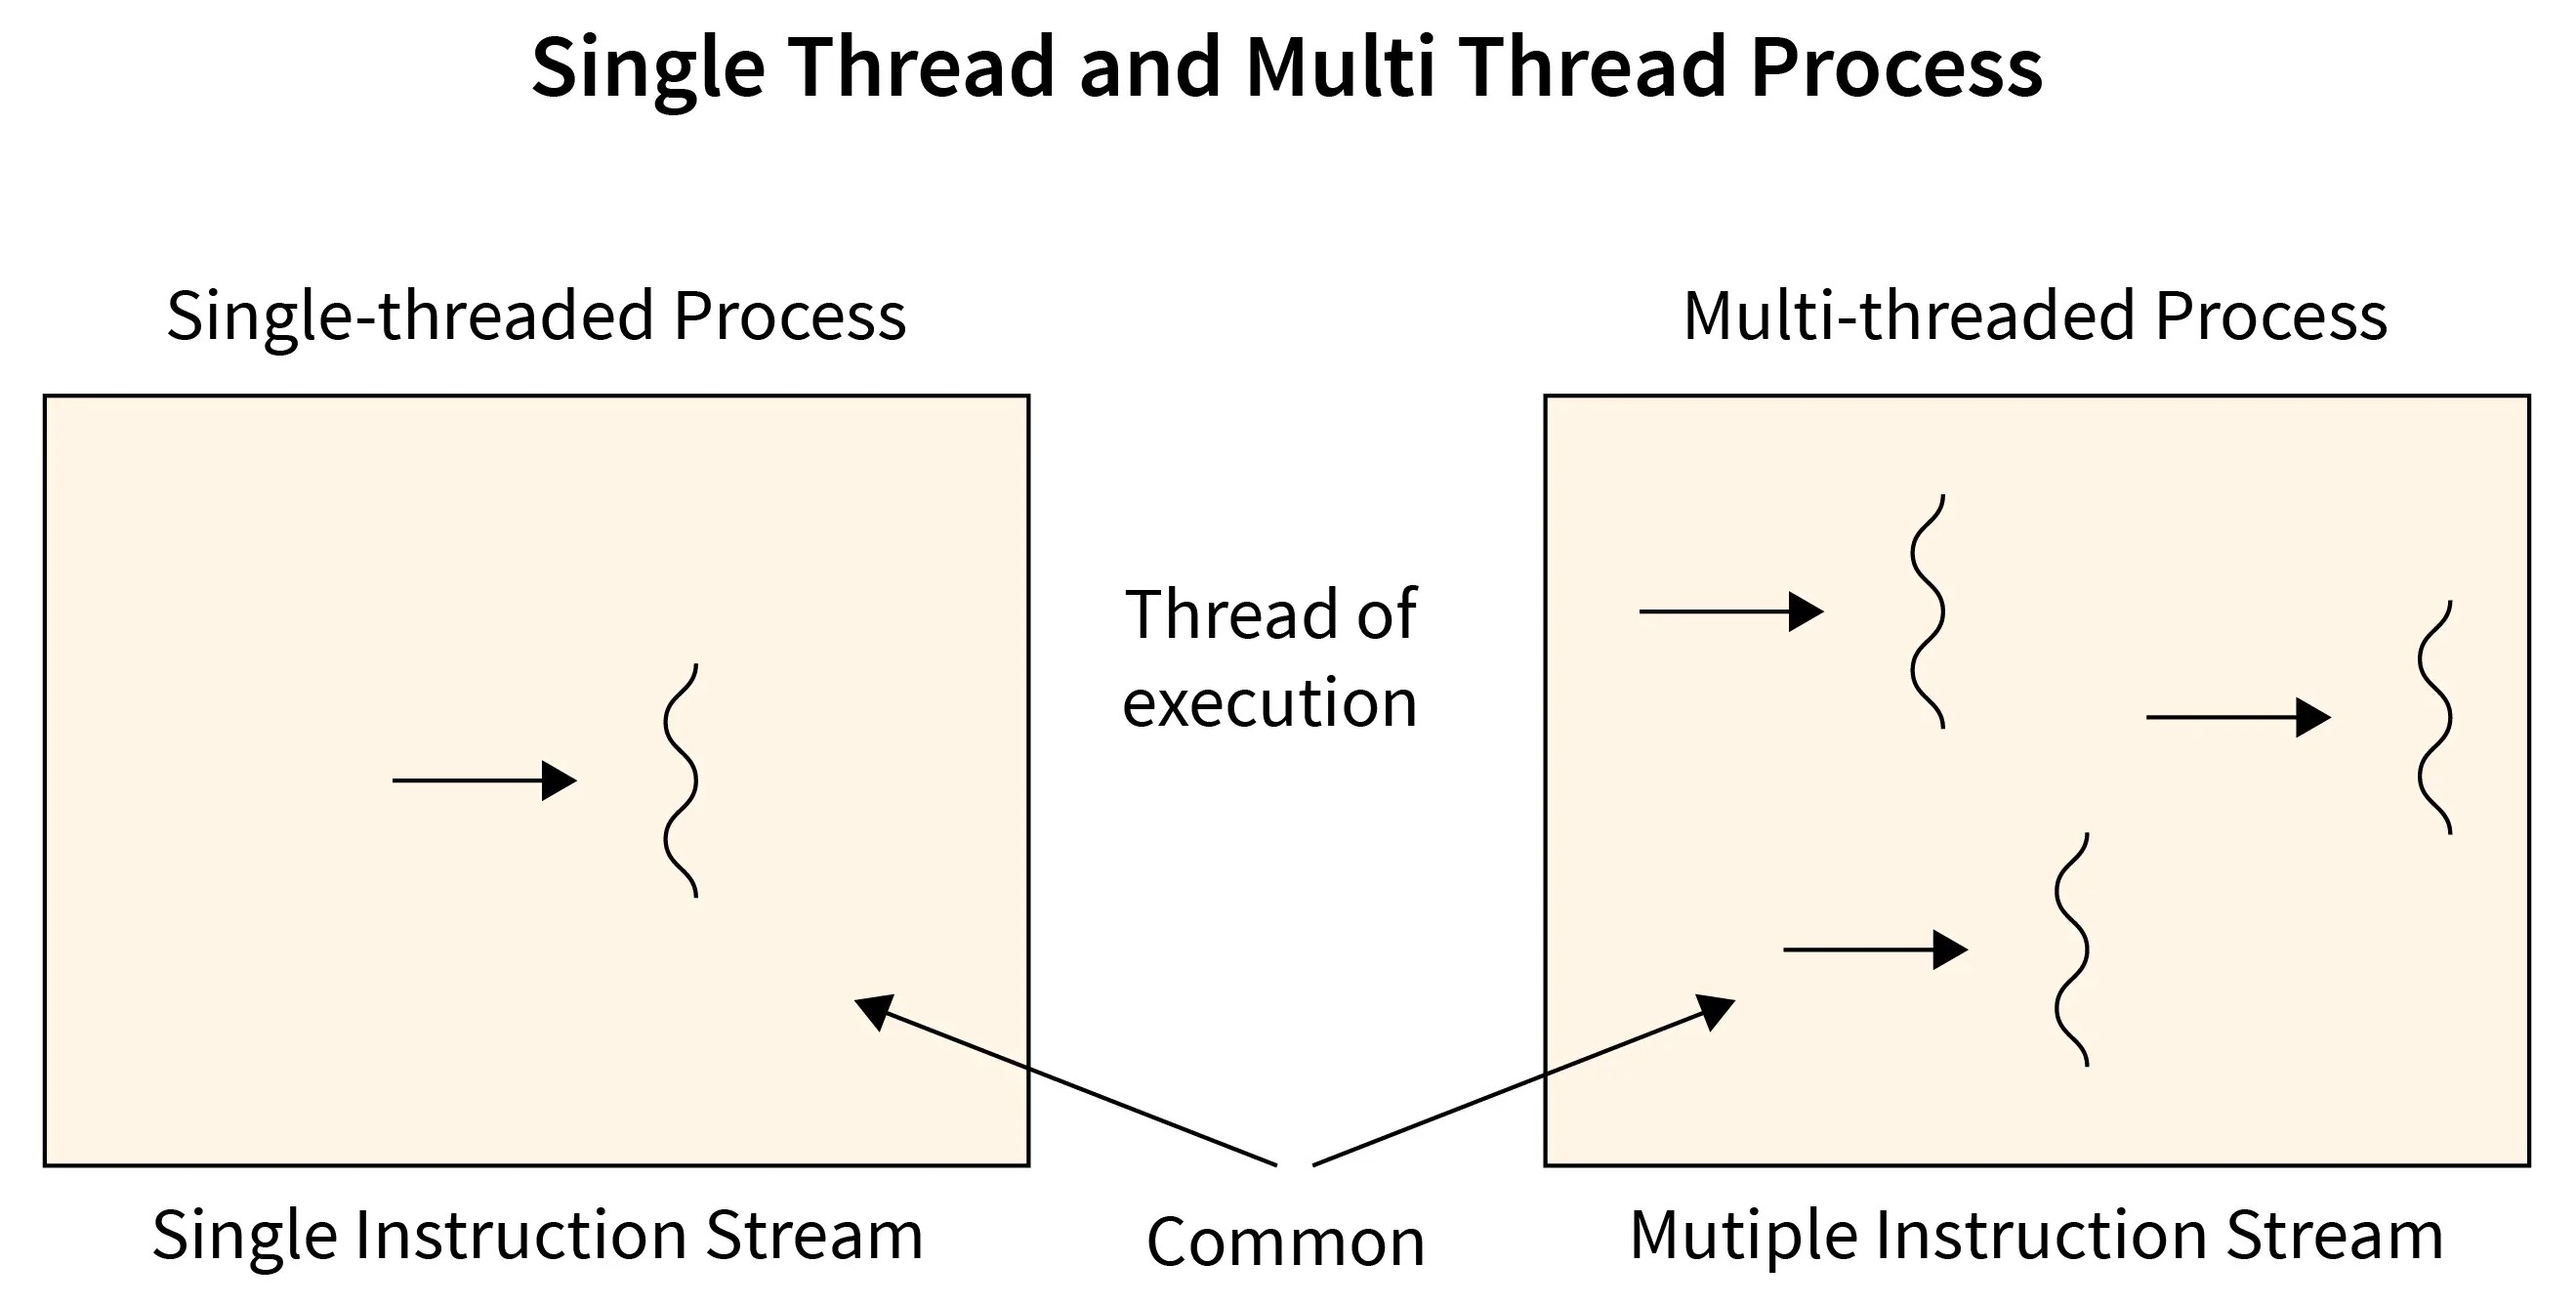

In [1]:
# Normally when we write programs, we tend to use only one thread.
# Every process has a single thread running which is called the main thread.
# What it does is it runs your code sequentially.

# But if you have some code which you had to use concurrently or simultaneously
# with some piece of code then you have to use multithreading

### What is a thread?

In [2]:
# Threads are typically basic unit of CPU utilization

# A single process can have multiple threads/codes running at the same time

# all the threads running share their code, data, files
# but every thread has different register and a separate stack of their own

### Why or When Threading?

suppose we have to run an application, have you ever wondered how the application
screen is kept alive?

so normally what everyone uses is a function dusplayScreen() that shows a
static image for a timeperiod lets say 1 ms, and then the screen goes away.

now whenwe allpy this function in a while loop -->
    
Main Thread

.
.
.

while(True):
    displayScreen()
    
.
.
.

this display function will show multiple images for a very short period of
time. it almost seems to feel that the application is runing whereas 
its just multiple images staying for a period of time and then going away.

lets assume we introduce a heavy function inside this while loop -->

Main Thread

.
.
.

while(True):
    
    // Heavy Operation
    
    displayScreen()
    
.
.
.

we will have a screen flicker
because this Heavy Operation needs to be before the displayScreen() function
runs, and shows your screen, so every time this loop runs your screen will
flicker, which is not a good user experence.

lets say we have a network call here -->

Main Thread

.
.
.

while(True):
    
    Image = request(ImageUrl)
    
    displayScreen()
    
.
.
.

now whenever this loop runs, it always call a network request, and the
screen will pop up after every second if its taking 1 sec, again
not a good user experence.

Now how can we use multithreading to solve this issue?

we will change the structure a bit -->

Main Thread

Image = NULL

.
.
.

startAnotherThread()
while(True):
    displayScreen(Image)
    
.
.
.

inside the AnotherThread() -->

while(True):
    
    Image = request(ImageUrl)

since all the threads of a process shared the process variables, this thread can catually 
use this image variable. now the display screen is not null, it can just
display the image whenever its available.

so by this way you can run concurrently multiple pieces of code.

In [3]:
# another ex where multithreading can be used is in servers, server can 
# service multile requests in different threads

### How threads are handled by OS?

In [4]:
# the statement threads running concurrently is actually not true

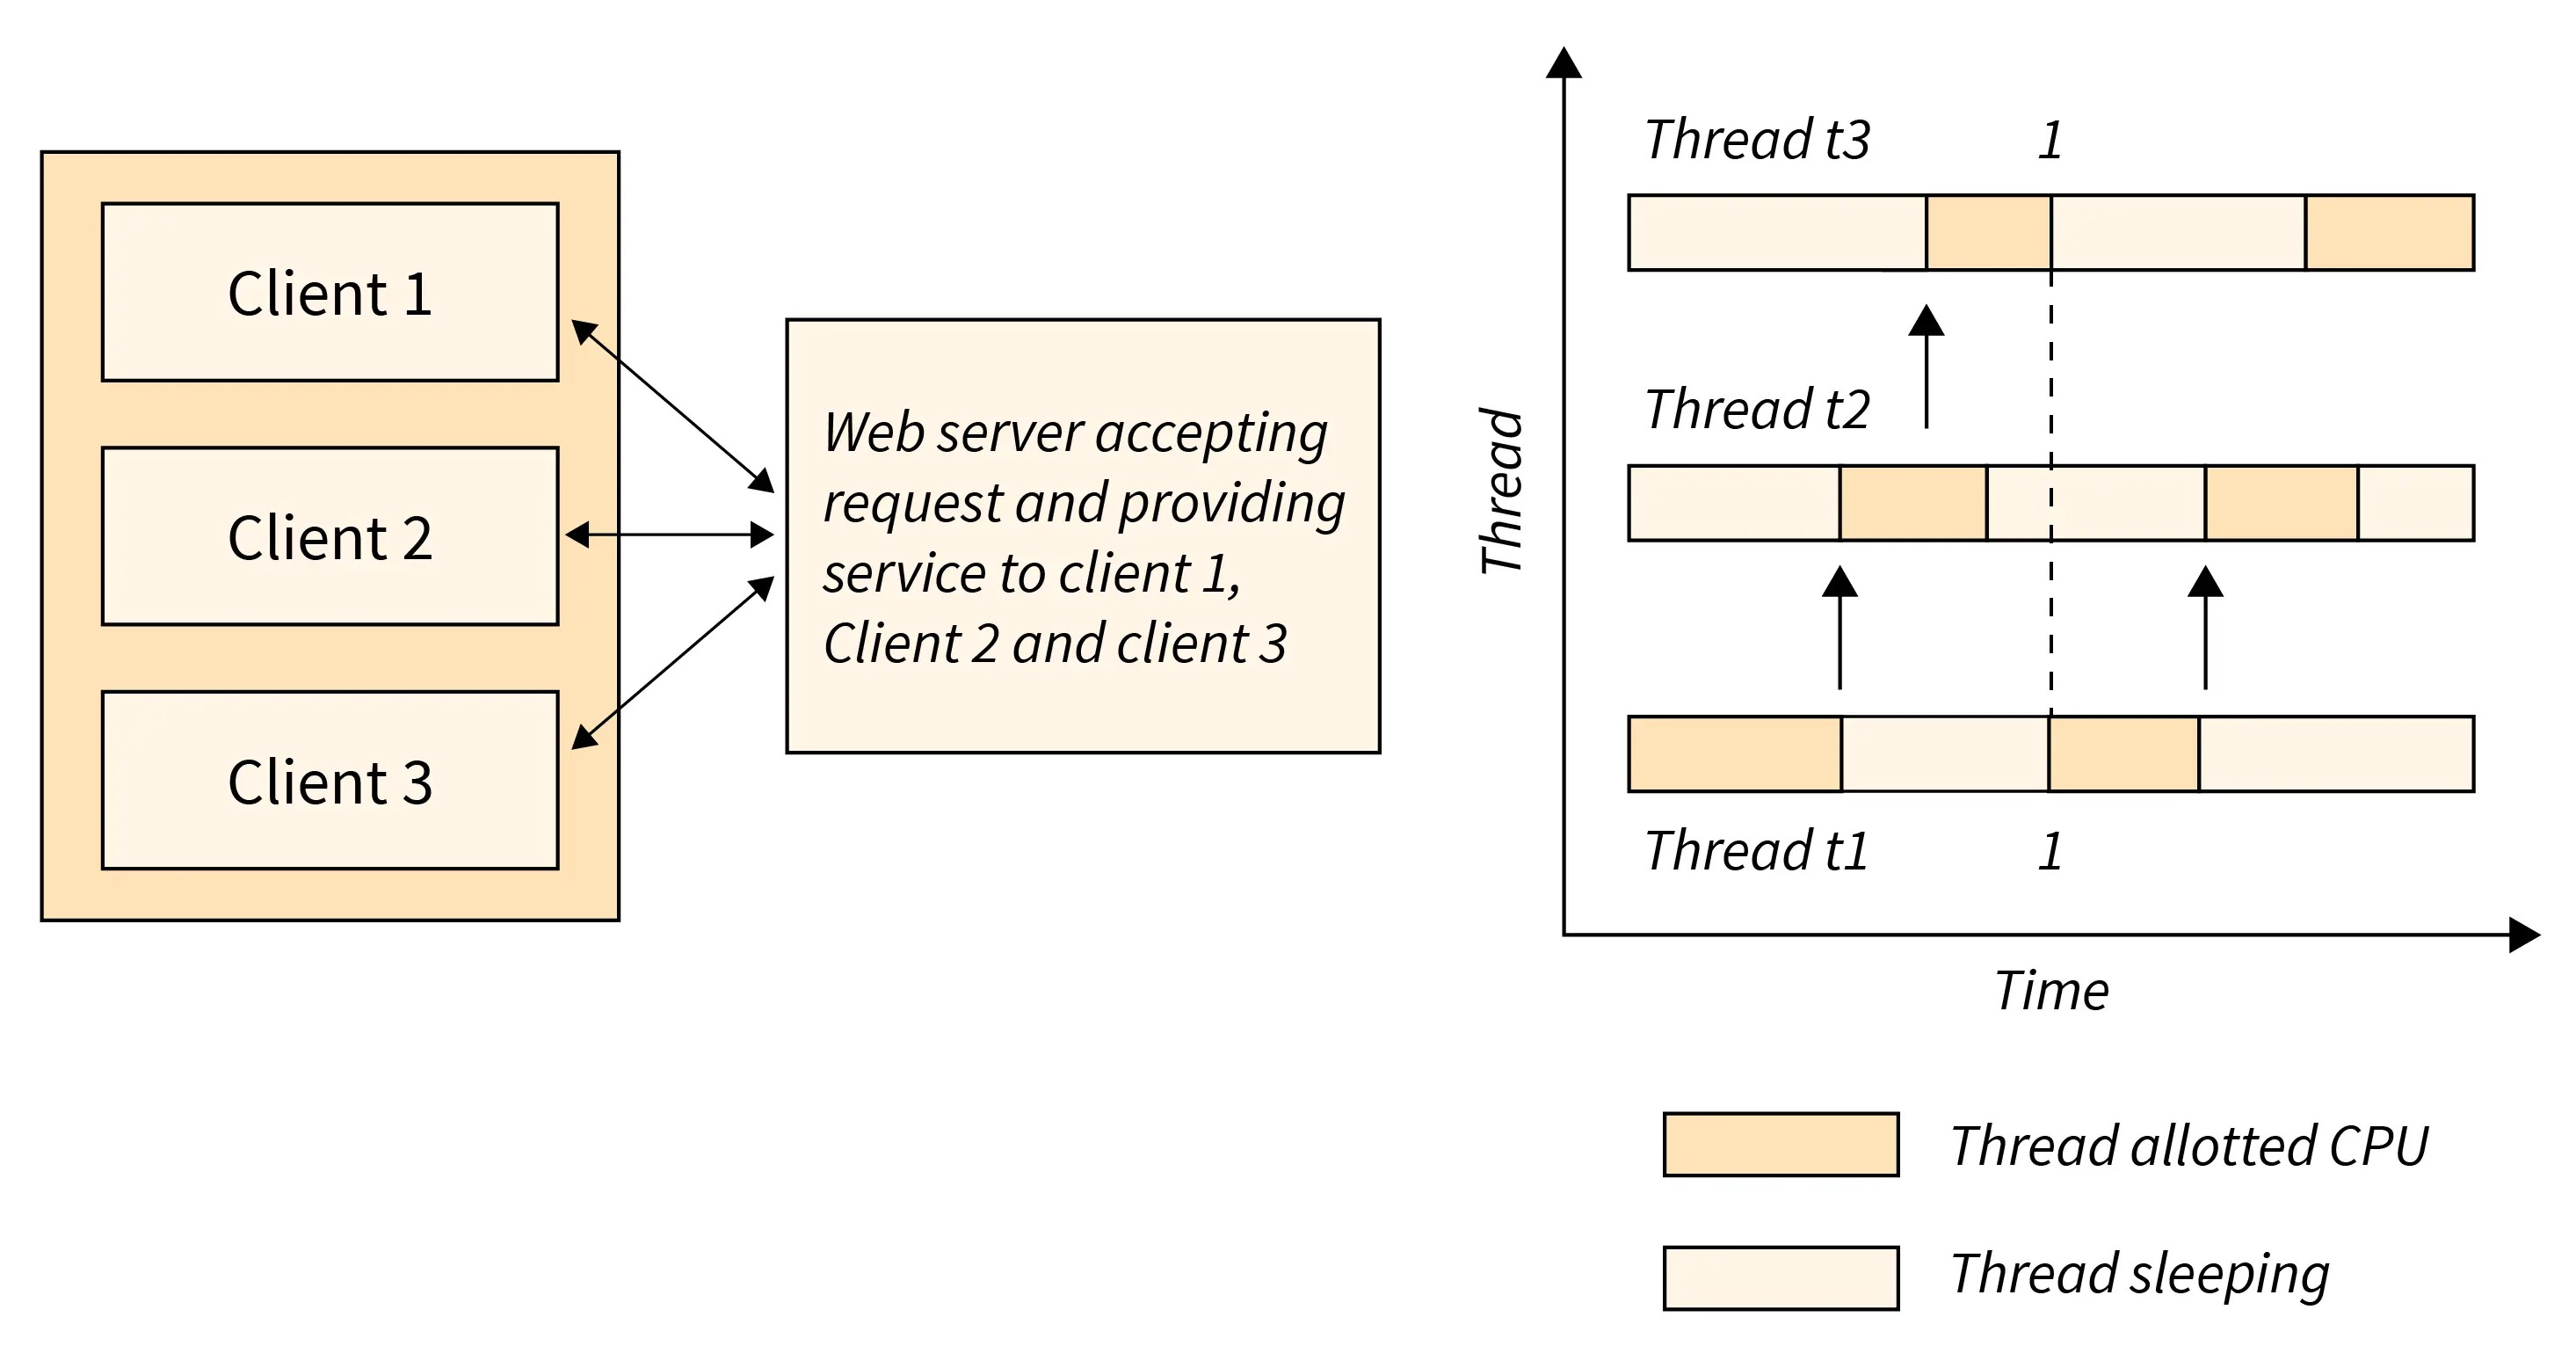

In [5]:
# lets say we have 3 threads, the cpu continuously switches between threads,
# at a point of time the cpu is executing only one thread, but since it 
# switches between threads it givesus the effect of concurrency

### Implementation

In [6]:
from time import sleep, time
import threading

start_time = time()
def something(id):
    print(f"Going to sleep...{id}")
    sleep(1)
    print(f"woken up ...{id}")
    
threads = [threading.Thread(target = something, args = [i]) for i in range(10)]

for thread in threads:
    thread.start()
    
for thread in threads:
    thread.join()
    
end_time = time()

print(f"Main Thread Ended in {end_time-start_time} seconds")

Going to sleep...0
Going to sleep...1
Going to sleep...2
Going to sleep...3
Going to sleep...4
Going to sleep...5
Going to sleep...6
Going to sleep...7
Going to sleep...8
Going to sleep...9
woken up ...9woken up ...7
woken up ...5
woken up ...8
woken up ...6
woken up ...4
woken up ...2
woken up ...3
woken up ...1
woken up ...0

Main Thread Ended in 1.0153999328613281 seconds


### Thread Synchronization

In [10]:
import threading

balance = 200

lock = threading.Lock()

def deposit(amount, times, lock):
    global balance
    
    for _ in range(times):
        lock.acquire()
        balance += amount
        lock.release()
        
def withdraw(amount, times, lock):
    global balance
    
    for _ in range(times):
        lock.acquire()
        balance -= amount
        lock.release()
        
deposit_thread = threading.Thread(target = deposit, args = [1, 100000, lock])
withdraw_thread = threading.Thread(target = withdraw, args = [1, 100000, lock])

deposit_thread.start()
withdraw_thread.start()

deposit_thread.join()
withdraw_thread.join()

print(balance)

200
